In [48]:
import pandas as pd
import json

with open("resultados_parametros.json") as f:
    resultados = json.load(f)

df_parametros = pd.DataFrame(resultados)
top10 = df_parametros.sort_values("ganancia_total", ascending=False).head(10)
print(top10[["RSI_LIMIT_COMPRA", "ADX_LIMIT", "MIN_VOTES", "SL_MULT", "TP_MULT", "ganancia_total", "winrate", "profit_factor", "max_drawdown"]])

     RSI_LIMIT_COMPRA  ADX_LIMIT  MIN_VOTES  SL_MULT  TP_MULT  ganancia_total  \
135                40         25          3      1.0      2.0          598.19   
138                40         25          3      1.5      2.0          596.30   
141                40         25          3      2.0      2.0          577.00   
137                40         25          3      1.0      3.5          561.01   
140                40         25          3      1.5      3.5          559.57   
136                40         25          3      1.0      3.0          544.96   
139                40         25          3      1.5      3.0          541.65   
143                40         25          3      2.0      3.5          531.92   
142                40         25          3      2.0      3.0          516.88   
126                40         23          5      1.0      2.0           26.30   

       winrate  profit_factor  max_drawdown  
135  42.523364       1.248886       1531.86  
138  43.689320  

In [49]:
import json
import shutil
import os

# Supón que 'mejor' es la mejor fila de tu DataFrame de parámetros
parametros_finales = mejor.to_dict()
parametros_finales_serializables = {k: (v.item() if hasattr(v, "item") else v) for k, v in parametros_finales.items()}

# 1. Haz un respaldo simple antes de sobrescribir
if os.path.exists("parametros_seleccionados.json"):
    shutil.copy("parametros_seleccionados.json", "parametros_seleccionados_backup.json")

# 2. Guarda los nuevos parámetros óptimos
with open('parametros_seleccionados.json', 'w') as f:
    json.dump(parametros_finales_serializables, f, indent=4)

print("✅ Parámetros óptimos actualizados en parametros_seleccionados.json (respaldo en parametros_seleccionados_backup.json)")

✅ Parámetros óptimos actualizados en parametros_seleccionados.json (respaldo en parametros_seleccionados_backup.json)


In [50]:
import sys
print(sys.executable)

c:\Users\lenovo\bot_trading\semana_5\.venv\Scripts\python.exe


In [51]:
# Primeros registros de cada archivo
pd.DataFrame(parametros).head()
df_backtesting.head()
df_operaciones.head()
df_historial.head()

,close,high,low,open,price,timestamp,volume
0,1823.96,1823.97,1822.55,1823.57,1823.96,1746484380000.0,152.7713
1,1822.60,1823.97,1822.20,1823.97,1822.60,1746484440000.0,182.9051
2,1823.99,1823.99,1822.60,1822.60,1823.99,1746484500000.0,197.1422
3,1824.48,1824.48,1823.68,1824.00,1824.48,1746484560000.0,179.0136
4,1824.65,1824.81,1824.00,1824.48,1824.65,1746484620000.0,110.4405


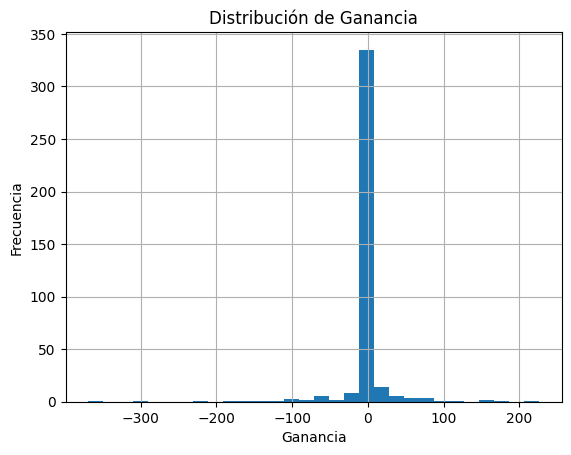

In [52]:
import matplotlib.pyplot as plt

try:
	df_backtesting['ganancia'].hist(bins=30)
	plt.title('Distribución de Ganancia')
	plt.xlabel('Ganancia')
	plt.ylabel('Frecuencia')
	plt.show()
except NameError:
	print("df_backtesting no está definido. Ejecuta primero la celda donde se carga el DataFrame.")

In [53]:
try:
	top10 = df_backtesting.sort_values('ganancia', ascending=False).head(10)
	display(top10)
except NameError:
	print("df_backtesting no está definido. Ejecuta primero la celda donde se carga el DataFrame.")

,tipo,precio,indice,timestamp,tipo_mercado,indicadores_usados,ganancia,duracion
665,venta,3451.52,3415,2025-01-15 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",225.89,1.0
757,venta,1756.26,3512,2025-04-22 00:00:00,desconocido,"['ADX', 'ATR']",176.69,1.0
667,venta,3473.63,3417,2025-01-17 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",165.58,1.0
653,venta,3609.01,3403,2025-01-03 00:00:00,desconocido,"['RSI', 'ADX', 'ATR']",153.34,1.0
723,venta,2056.06,3478,2025-03-19 00:00:00,desconocido,"['ADX', 'ATR']",124.52,1.0
673,venta,3338.21,3423,2025-01-23 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",95.61,1.0
693,venta,2744.05,3448,2025-02-17 00:00:00,desconocido,"['ADX', 'ATR']",82.64,1.0
747,venta,1644.18,3502,2025-04-12 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",77.33,1.0
647,venta,3404.00,3397,2024-12-28 00:00:00,desconocido,"['RSI', 'ADX', 'BB_Upper', 'ATR']",70.49,1.0
709,venta,2241.59,3464,2025-03-05 00:00:00,desconocido,"['ADX', 'MACD_hist', 'Ichimoku_Tenkan', 'ATR']",70.08,1.0


In [54]:
df_backtesting.describe()

,precio,indice,ganancia,duracion
count,790.000000,790.000000,395.00000,395.000000
mean,1907.371063,1706.022785,-1.97362,3.306329
std,350.077614,1076.859435,40.80565,3.999345
min,1473.410000,33.000000,-369.10000,1.000000
25%,1795.362500,800.750000,-1.72000,1.000000
50%,1813.925000,1553.500000,-0.46000,1.000000
75%,1833.870000,2355.750000,1.03500,4.000000
max,3687.450000,3711.000000,225.89000,18.000000


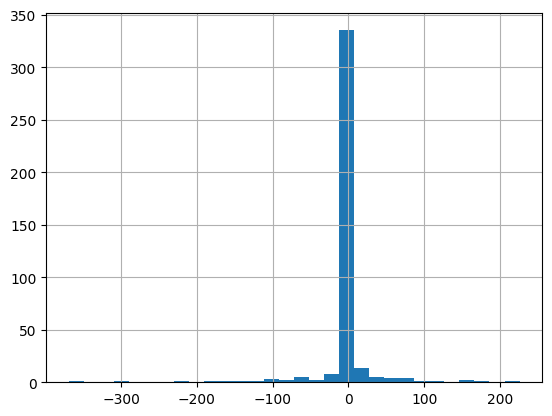

In [55]:
# Gráficos de distribución de métricas de backtesting
df_backtesting['ganancia'].hist(bins=30)
if 'max_drawdown' in df_backtesting.columns:
    df_backtesting['max_drawdown'].hist(bins=30)
    plt.title('Distribución de Max Drawdown')
    plt.xlabel('Max Drawdown')
    plt.ylabel('Frecuencia')
    plt.show()

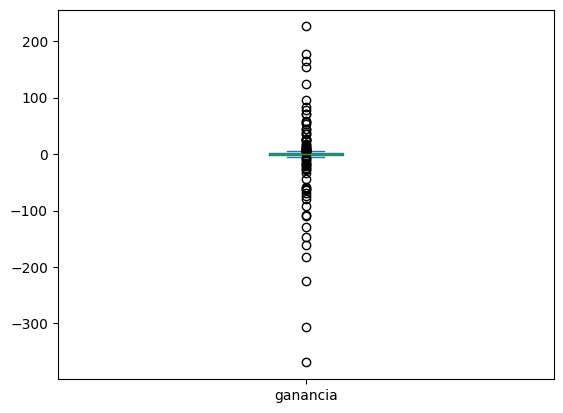

In [56]:
df_backtesting  ['ganancia'].plot(kind='box')   
if 'max_drawdown' in df_backtesting.columns:
    robustas = df_backtesting[
        (df_backtesting['ganancia'] > df_backtesting['ganancia'].median()) &
        (df_backtesting['max_drawdown'] < df_backtesting['max_drawdown'].median())
    ]
    robustas.sort_values('ganancia', ascending=False).head(10)

In [57]:
if 'saldo' in df_operaciones.columns:
    df_operaciones['saldo'].plot(title='Curva de saldo')
    plt.xlabel('N° de operación')
    plt.ylabel('Saldo')
    plt.show()

In [58]:
# Mostrar solo las columnas disponibles en top10
try:
	top10
except NameError:
	top10 = df_backtesting.sort_values('ganancia', ascending=False).head(10)
top10[['tipo', 'precio', 'indice', 'timestamp', 'tipo_mercado', 'indicadores_usados', 'ganancia', 'duracion']]

,tipo,precio,indice,timestamp,tipo_mercado,indicadores_usados,ganancia,duracion
665,venta,3451.52,3415,2025-01-15 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",225.89,1.0
757,venta,1756.26,3512,2025-04-22 00:00:00,desconocido,"['ADX', 'ATR']",176.69,1.0
667,venta,3473.63,3417,2025-01-17 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",165.58,1.0
653,venta,3609.01,3403,2025-01-03 00:00:00,desconocido,"['RSI', 'ADX', 'ATR']",153.34,1.0
723,venta,2056.06,3478,2025-03-19 00:00:00,desconocido,"['ADX', 'ATR']",124.52,1.0
673,venta,3338.21,3423,2025-01-23 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",95.61,1.0
693,venta,2744.05,3448,2025-02-17 00:00:00,desconocido,"['ADX', 'ATR']",82.64,1.0
747,venta,1644.18,3502,2025-04-12 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",77.33,1.0
647,venta,3404.00,3397,2024-12-28 00:00:00,desconocido,"['RSI', 'ADX', 'BB_Upper', 'ATR']",70.49,1.0
709,venta,2241.59,3464,2025-03-05 00:00:00,desconocido,"['ADX', 'MACD_hist', 'Ichimoku_Tenkan', 'ATR']",70.08,1.0


In [59]:
# Combinaciones con alta ganancia y bajo drawdown
if 'max_drawdown' in df_backtesting.columns:
    df_backtesting['max_drawdown'].plot(kind='box')
    plt.title('Boxplot de Max Drawdown')
    plt.ylabel('Max Drawdown')
    plt.show()
    # Filtrar combinaciones robustas solo si existe la columna
    df_backtesting_filtrado = df_backtesting[
        (df_backtesting['ganancia'] > df_backtesting['ganancia'].median()) &
        (df_backtesting['max_drawdown'] < df_backtesting['max_drawdown'].median())
    ]
    robustas = df_backtesting_filtrado[
        (df_backtesting_filtrado['ganancia'] > df_backtesting_filtrado['ganancia'].median()) &
        (df_backtesting_filtrado['max_drawdown'] < df_backtesting_filtrado['max_drawdown'].median())
    ]
    robustas.sort_values('ganancia', ascending=False).head(10)
else:
    print("La columna 'max_drawdown' no está disponible en df_backtesting.")

La columna 'max_drawdown' no está disponible en df_backtesting.


In [60]:
# Asegura que top10 esté definido
try:
    top10
except NameError:
    top10 = df_backtesting.sort_values('ganancia', ascending=False).head(10)

# Filtrar df_operaciones por los mismos valores clave de la mejor combinación
mejor = top10.iloc[0]
filtro = (
    (df_operaciones['tipo'] == mejor['tipo']) &
    (df_operaciones['precio'] == mejor['precio']) &
    (df_operaciones['indice'] == mejor['indice']) &
    (df_operaciones['timestamp'] == mejor['timestamp']) &
    (df_operaciones['tipo_mercado'] == mejor['tipo_mercado'])
)
# Si tienes una columna 'saldo', plotea la curva de saldo
if 'saldo' in df_operaciones.columns:
    df_operaciones[filtro]['saldo'].plot(title='Curva de saldo de la mejor combinación')
    plt.xlabel('N° de operación')
    plt.ylabel('Saldo')
    plt.show()
else:
    print("La columna 'saldo' no está disponible en df_operaciones.")

La columna 'saldo' no está disponible en df_operaciones.


In [61]:
if 'fecha' in df_operaciones.columns:
    df_operaciones.groupby('fecha')['saldo'].last().plot(title='Evolución diaria del saldo')
    plt.xlabel('Fecha')
    plt.ylabel('Saldo')
    plt.show()

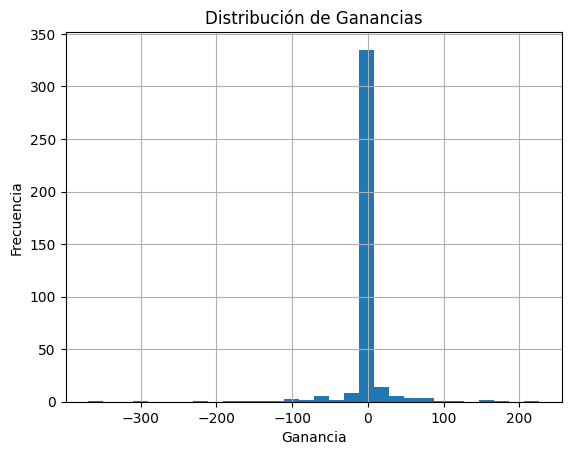

In [62]:
# Gráficos de distribución de métricas adicionales
if 'ganancia' in df_backtesting.columns:
    df_backtesting['ganancia'].hist(bins=30)
    plt.title('Distribución de Ganancias')
    plt.xlabel('Ganancia')
    plt.ylabel('Frecuencia')
    plt.show()
if 'profit_factor' in df_backtesting.columns:
    df_backtesting['profit_factor'].hist(bins=30)
    plt.title('Distribución de Profit Factor')
    plt.xlabel('Profit Factor')
    plt.ylabel('Frecuencia')
    plt.show()

In [63]:
import json

# Selección automática: alta ganancia y bajo drawdown
if 'max_drawdown' in df_backtesting.columns:
    robustos = df_backtesting[
        (df_backtesting['ganancia'] > df_backtesting['ganancia'].median()) &
        (df_backtesting['max_drawdown'] < df_backtesting['max_drawdown'].median())
    ]
    mejor = robustos.sort_values('ganancia', ascending=False).iloc[0]
else:
    mejor = df_backtesting.sort_values('ganancia', ascending=False).iloc[0]

# Guarda todos los parámetros de la mejor combinación
parametros_finales = mejor.to_dict()

# Convierte los valores a tipos nativos de Python para evitar errores de serialización
parametros_finales_serializables = {k: (v.item() if hasattr(v, "item") else v) for k, v in parametros_finales.items()}

# Guarda los parámetros en un JSON
with open('parametros_seleccionados.json', 'w') as f:
    json.dump(parametros_finales_serializables, f, indent=4)

print("Parámetros robustos guardados en parametros_seleccionados.json")

Parámetros robustos guardados en parametros_seleccionados.json


In [64]:
top10 = df_backtesting.sort_values('ganancia', ascending=False).head(10)
display(top10)  # Si usas Jupyter, esto muestra una tabla bonita
# O si no tienes display:
print(top10[['ganancia', 'tipo', 'precio', 'indice', 'timestamp', 'tipo_mercado', 'indicadores_usados', 'duracion']])
print(df_backtesting.columns)

,tipo,precio,indice,timestamp,tipo_mercado,indicadores_usados,ganancia,duracion
665,venta,3451.52,3415,2025-01-15 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",225.89,1.0
757,venta,1756.26,3512,2025-04-22 00:00:00,desconocido,"['ADX', 'ATR']",176.69,1.0
667,venta,3473.63,3417,2025-01-17 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",165.58,1.0
653,venta,3609.01,3403,2025-01-03 00:00:00,desconocido,"['RSI', 'ADX', 'ATR']",153.34,1.0
723,venta,2056.06,3478,2025-03-19 00:00:00,desconocido,"['ADX', 'ATR']",124.52,1.0
673,venta,3338.21,3423,2025-01-23 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",95.61,1.0
693,venta,2744.05,3448,2025-02-17 00:00:00,desconocido,"['ADX', 'ATR']",82.64,1.0
747,venta,1644.18,3502,2025-04-12 00:00:00,desconocido,"['ADX', 'MACD_hist', 'ATR']",77.33,1.0
647,venta,3404.00,3397,2024-12-28 00:00:00,desconocido,"['RSI', 'ADX', 'BB_Upper', 'ATR']",70.49,1.0
709,venta,2241.59,3464,2025-03-05 00:00:00,desconocido,"['ADX', 'MACD_hist', 'Ichimoku_Tenkan', 'ATR']",70.08,1.0


     ganancia   tipo   precio  indice            timestamp tipo_mercado  \
665    225.89  venta  3451.52    3415  2025-01-15 00:00:00  desconocido   
757    176.69  venta  1756.26    3512  2025-04-22 00:00:00  desconocido   
667    165.58  venta  3473.63    3417  2025-01-17 00:00:00  desconocido   
653    153.34  venta  3609.01    3403  2025-01-03 00:00:00  desconocido   
723    124.52  venta  2056.06    3478  2025-03-19 00:00:00  desconocido   
673     95.61  venta  3338.21    3423  2025-01-23 00:00:00  desconocido   
693     82.64  venta  2744.05    3448  2025-02-17 00:00:00  desconocido   
747     77.33  venta  1644.18    3502  2025-04-12 00:00:00  desconocido   
647     70.49  venta  3404.00    3397  2024-12-28 00:00:00  desconocido   
709     70.08  venta  2241.59    3464  2025-03-05 00:00:00  desconocido   

                                 indicadores_usados  duracion  
665                     ['ADX', 'MACD_hist', 'ATR']       1.0  
757                                  ['ADX', '